# TvZ XGBoost Model
This notebook trains and xgboost model to predict the winner of a Terran vs Zerg SC2 game.

## Setup

In [1]:
import pandas as pd
import xgboost as xgb

from starcraft_predictor.processing.data_splitter import train_test_split

In [4]:
data = pd.read_pickle("../data/Terran_vs_Zerg.pkl")

In [5]:
data.head()

,filehash,winner,player_1_race,player_2_race,seconds,player_1_food_made,player_2_food_made,player_1_food_used,player_2_food_used,player_1_minerals_collection_rate,...,player_2_Frenzy,player_2_ZergFlyerWeaponsLevel1,player_2_ZergFlyerWeaponsLevel2,player_2_ZergFlyerWeaponsLevel3,player_2_AnabolicSynthesis,player_2_NeuralParasite,player_2_ZergFlyerArmorsLevel1,player_2_ZergFlyerArmorsLevel2,player_2_ZergFlyerArmorsLevel3,player_2_TunnelingClaws
0,17d734f0ced7d98ffcbdf7c113fb40a96548872495edf3...,2,Terran,Zerg,0,15.0,14.0,12.0,12.0,0,...,0,0,0,0,0,0,0,0,0,0
1,17d734f0ced7d98ffcbdf7c113fb40a96548872495edf3...,2,Terran,Zerg,10,15.0,14.0,13.0,13.0,293,...,0,0,0,0,0,0,0,0,0,0
2,17d734f0ced7d98ffcbdf7c113fb40a96548872495edf3...,2,Terran,Zerg,20,15.0,14.0,14.0,13.0,643,...,0,0,0,0,0,0,0,0,0,0
3,17d734f0ced7d98ffcbdf7c113fb40a96548872495edf3...,2,Terran,Zerg,30,15.0,14.0,14.0,14.0,643,...,0,0,0,0,0,0,0,0,0,0
4,17d734f0ced7d98ffcbdf7c113fb40a96548872495edf3...,2,Terran,Zerg,40,15.0,14.0,15.0,14.0,699,...,0,0,0,0,0,0,0,0,0,0


In [6]:
NON_FEATURES = [
    "filehash",
    "winner",
    "player_1_race",
    "player_2_race",
]

FEATURES = [col for col in data.columns if col not in NON_FEATURES]

## Clean Data

In [7]:
# convert target to 0, 1
data["winner"] = data["winner"] - 1

In [8]:
data["filehash"].nunique()

302

In [9]:
data["winner"].mean()

np.float64(0.4727267841788478)

In [10]:
train_data, test_data = train_test_split(data, "filehash", 0.2)

In [11]:
train_data.shape, test_data.shape

((31055, 132), (6161, 132))

In [43]:
import pandas as pd
import numpy as np

def select_random_row_per_filehash(df: pd.DataFrame, filehash_column: str = 'filehash') -> pd.DataFrame:
    """
    Select a single random row for each unique filehash in the DataFrame.
    
    Args:
        df (pd.DataFrame): Input DataFrame containing the filehash column
        filehash_column (str): Name of the column containing filehashes. Defaults to 'filehash'
        
    Returns:
        pd.DataFrame: DataFrame containing one random row per unique filehash
    """
    # Group by filehash and apply a random selection
    return df.groupby(filehash_column).apply(lambda x: x.sample(n=1)).reset_index(drop=True)

In [44]:
train_data.sort_values(["filehash", "seconds"], ascending=True, inplace=True)
test_data.sort_values(["filehash", "seconds"], ascending=True, inplace=True)

train_data_single_event = select_random_row_per_filehash(train_data)
test_data_single_event = select_random_row_per_filehash(test_data)

/var/folders/hl/1wwnp4rj1091jv34r4wfvckm0000gn/T/ipykernel_1337/2317186512.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(filehash_column).apply(lambda x: x.sample(n=1)).reset_index(drop=True)
/var/folders/hl/1wwnp4rj1091jv34r4wfvckm0000gn/T/ipykernel_1337/2317186512.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(filehash_column).apply(lambda x: x.sample(n=1)).reset_ind

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
PARAMS = {
    "n_estimators": 1000,
    "random_state": 123,
    "subsample": 0.5,
    "colsample_bytree": 0.5,
    "early_stopping_rounds": 5,
    "eval_metric": "logloss",
    "gamma": 0.1,
}

In [47]:
model = xgb.XGBClassifier(**PARAMS)

In [56]:
model.fit(
    X=train_data[FEATURES],
    y=train_data["winner"],
    eval_set=[
        (train_data[FEATURES], train_data["winner"]),
        (test_data[FEATURES], test_data["winner"])
    ],
)

[0]	validation_0-logloss:0.65464	validation_1-logloss:0.67850
[1]	validation_0-logloss:0.61155	validation_1-logloss:0.65549
[2]	validation_0-logloss:0.58694	validation_1-logloss:0.64599
[3]	validation_0-logloss:0.56103	validation_1-logloss:0.63736
[4]	validation_0-logloss:0.53983	validation_1-logloss:0.63443
[5]	validation_0-logloss:0.53159	validation_1-logloss:0.63680
[6]	validation_0-logloss:0.51799	validation_1-logloss:0.64061
[7]	validation_0-logloss:0.50577	validation_1-logloss:0.64198
[8]	validation_0-logloss:0.48869	validation_1-logloss:0.64406


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,5
,enable_categorical,False
,eval_metric,'logloss'


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=5,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [57]:
preds = model.predict_proba(test_data[FEATURES])[:, 1]

In [58]:
output = test_data[["filehash", "seconds", "winner"]].copy()

In [59]:
output["predictions"] = preds

In [60]:
from sklearn.metrics import brier_score_loss, roc_auc_score
import numpy as np

In [61]:
def evaluate_for_specific_minute(data, minute):
    subset = data[data["seconds"] == minute*60]
    count = subset.shape[0]
    brier_score = brier_score_loss(subset["winner"], subset["predictions"])
    roc_auc = roc_auc_score(subset["winner"], subset["predictions"])
    return brier_score, roc_auc, count

/Users/nedwebster/Documents/python_projects/personal_projects/starcraft_predictor/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


(0.0, 1.0)

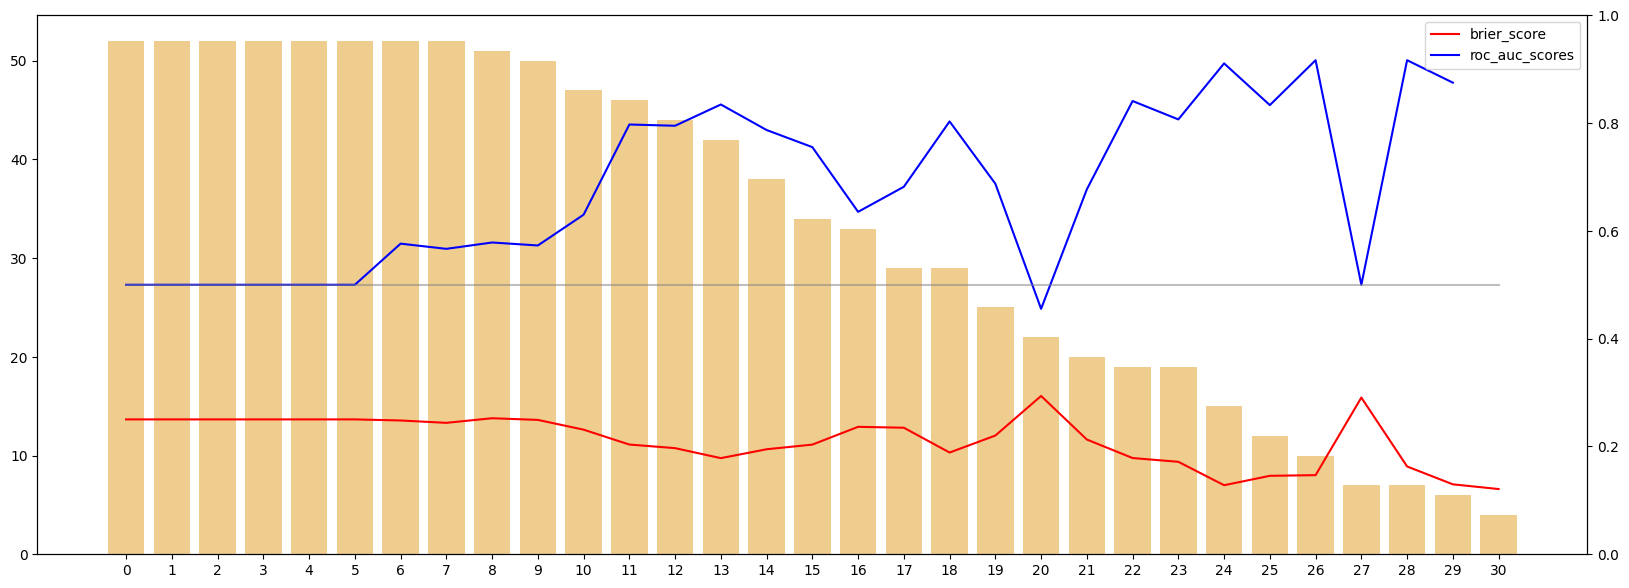

In [62]:
brier_scores = []
roc_aucs = []
counts = []
for i in range(0, 31):
    brier_score, roc_auc, count = evaluate_for_specific_minute(output, i)
    brier_scores.append(brier_score)
    roc_aucs.append(roc_auc)
    counts.append(count)

fig, ax = plt.subplots(figsize=(20, 7))
sns.barplot(x=np.arange(0, 31), y=counts, color="orange", alpha=0.5)

ax2 = ax.twinx()

sns.lineplot(x=np.arange(0, 31), y=brier_scores, label="brier_score", color="red")
sns.lineplot(x=np.arange(0, 31), y=roc_aucs, label="roc_auc_scores", color="blue")
sns.lineplot(x=np.arange(0, 31), y=0.5, color="grey", alpha=0.5)

ax2.set_ylim(0, 1)